Assignment 2 — Real Estate Price Prediction (Feature Engineering)
Objective
Predict house prices using Linear Regression with extensive feature engineering.
Dataset
Participants must find dataset from Kaggle.
Example:
House Prices Dataset
Typical features:
• area
• bedrooms
• bathrooms
• location
• age of house
• parking
• furnishing
Tasks
1. Load dataset.
2. Perform EDA (Exploratory Data Analysis):
o correlation matrix
o pair plots
3. Handle:
o missing values
o categorical variables
4. Apply:
o One-hot encoding
5. Detect multicollinearity using VIF.
6. Train multiple models:
o Simple Linear Regression
o Multiple Linear Regression
7. Compare models using:
• MAE
• RMSE
• R²
Visualization
Participants must plot:
• correlation heatmap
• residual plots
• predicted vs actual
Analysis Questions
Participants must answer:
1. Which features most influence price?
2. Which features cause multicollinearity?
3. How did feature engineering improve the model?

1. Import Libraries

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

2. Load Dataset

In [4]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


3. Dataset Overview

In [5]:
df.shape

(545, 13)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Check missing values

In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

4. Exploratory Data Analysis (EDA)
Correlation Matrix

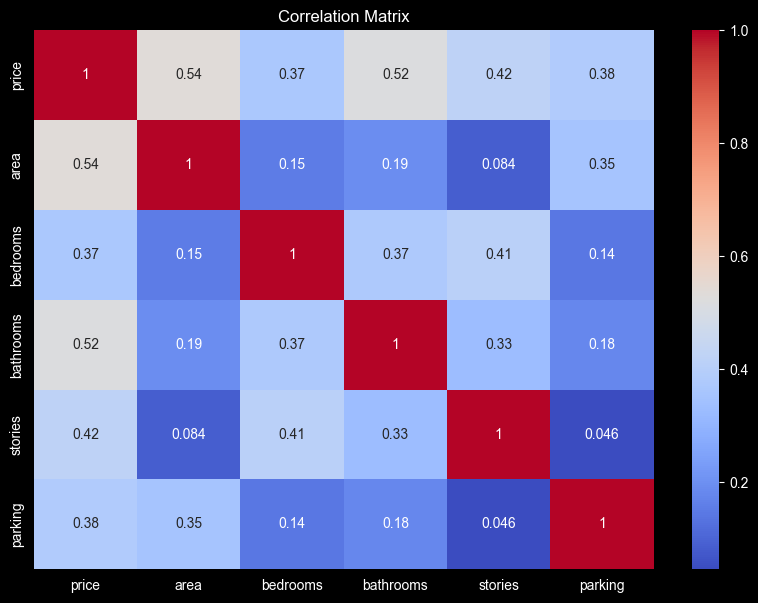

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Pair Plot

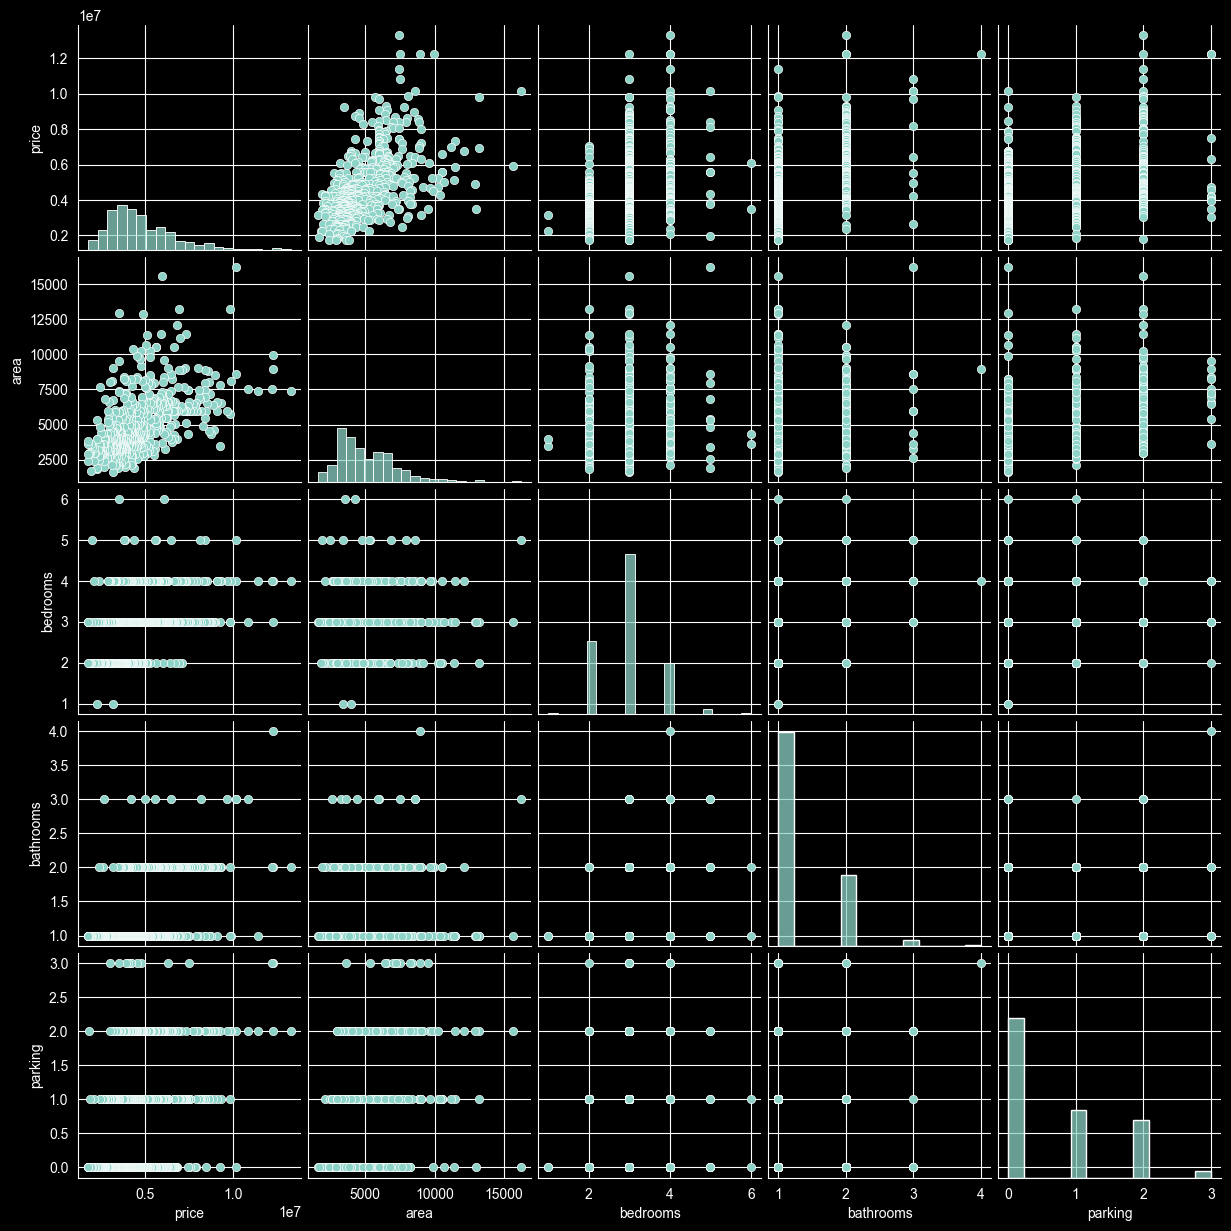

In [10]:
sns.pairplot(df[['price','area','bedrooms','bathrooms','parking']])

plt.show()

Handle Categorical Variables

Columns that are categorical:

mainroad
guestroom
basement
hotwaterheating
airconditioning
prefarea
furnishingstatus

In [21]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

Apply One-Hot Encoding

In [22]:
categorical_cols = ['mainroad', 'guestroom', 'basement',
                    'hotwaterheating', 'airconditioning',
                    'prefarea', 'furnishingstatus']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [23]:
df_encoded = df_encoded.astype(int)

In [24]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

7. Detect Multicollinearity using VIF

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

vif

,Feature,VIF
0,area,8.276447
1,bedrooms,16.652387
2,bathrooms,9.417643
3,stories,7.880730
4,parking,1.986400
5,mainroad_yes,6.884806
6,guestroom_yes,1.473234
7,basement_yes,2.019858
8,hotwaterheating_yes,1.091568
9,airconditioning_yes,1.767753


Simple Linear Regression

In [26]:

# Simple regression using area
X_simple = df[['area']]
y_simple = df['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)

Multiple Linear Regression

In [27]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

y_pred_multiple = multiple_model.predict(X_test)

Model Evaluation
MAE

In [28]:
mae_simple = mean_absolute_error(y_test_s, y_pred_simple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)

RMSE

In [29]:
rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

R² Score

In [30]:
r2_simple = r2_score(y_test_s, y_pred_simple)
r2_multiple = r2_score(y_test, y_pred_multiple)

Compare Models

In [31]:

comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MAE": [mae_simple, mae_multiple],
    "RMSE": [rmse_simple, rmse_multiple],
    "R2 Score": [r2_simple, r2_multiple]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Simple Linear Regression,1.474748e+06,1.917104e+06,0.272879
1,Multiple Linear Regression,9.700434e+05,1.324507e+06,0.652924


Visualization

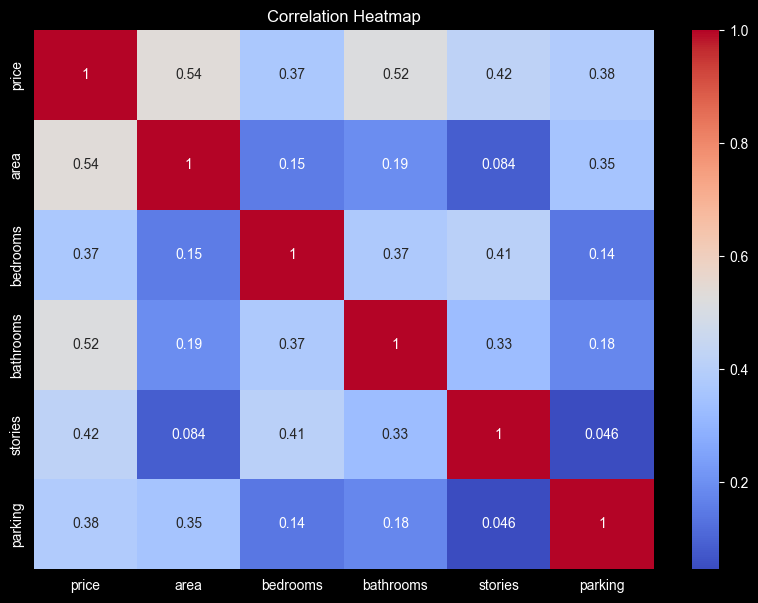

In [32]:


plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

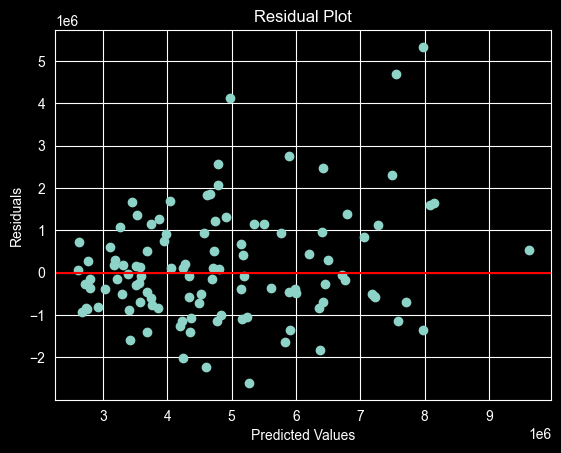

In [33]:
residuals = y_test - y_pred_multiple

plt.scatter(y_pred_multiple, residuals)
plt.axhline(0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.show()

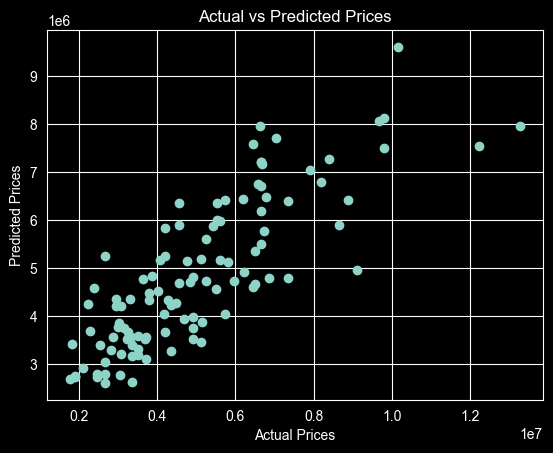

In [34]:
plt.scatter(y_test, y_pred_multiple)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")
plt.show()

Which features most influence price?

From correlation analysis and regression coefficients, the most influential features are:
area
bathrooms
airconditioning
parking
prefarea
Among them, **area has the strongest impact on house price.**

Which features cause multicollinearity?

Using Variance Inflation Factor (VIF):
The feature bedrooms has the highest **VIF value (16.65), indicating strong multicollinearity with variables like area and bathrooms.**

How did feature engineering improve the model?

Feature engineering improved the model by:

Converting categorical variables using One-Hot Encoding

Removing multicollinearity using VIF analysis

Selecting meaningful features for prediction

These steps improved model performance by:

reducing prediction error (lower MAE and RMSE)

increasing R² score

making the regression model more stable and accurate.